<a href="https://www.kaggle.com/code/nikita2901699/practical-nn?scriptVersionId=293184235" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [11]:
import torch  
from torchvision import datasets, transforms 

In [12]:
data_dir = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_0"

In [13]:
dataset0 = datasets.ImageFolder(data_dir)

In [14]:
len(dataset0)

3527

In [15]:
img, label = dataset0[3526]

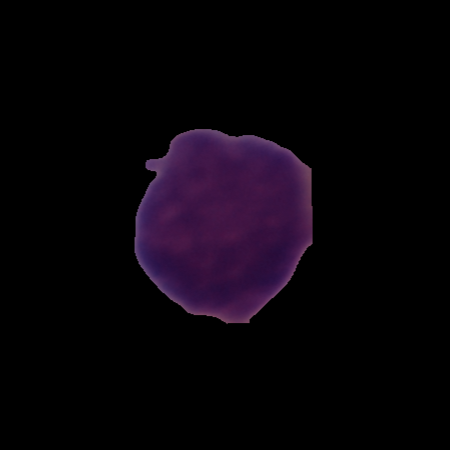

In [16]:
img

In [17]:
dataset0.classes

['all', 'hem']

In [18]:
data_dir1 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_1"
dataset1 = datasets.ImageFolder(data_dir1)

data_dir2 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_2"
dataset2 = datasets.ImageFolder(data_dir2)

In [19]:
dataset0.classes
dataset1.classes
dataset2.classes

['all', 'hem']

In [20]:
dataset_all = torch.utils.data.ConcatDataset([dataset0, dataset1, dataset2])

In [21]:
len(dataset_all)

10661

In [22]:
data_train, data_test = torch.utils.data.random_split(dataset_all,[0.8, 0.2])

In [23]:
len(data_train)


8529

In [24]:
len(data_test)


2132

In [25]:
img, label = data_train[5000]

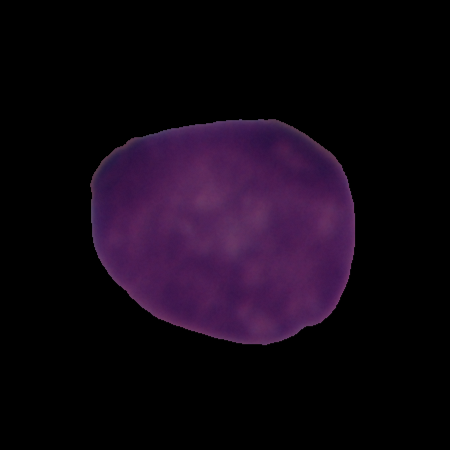

In [26]:
img

In [27]:
train_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
    transforms.CenterCrop(60),
    transforms.RandomRotation(180),
    transforms.ToTensor()
    ]
)

In [28]:
train_transform(img).shape

torch.Size([3, 60, 60])

In [29]:
test_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
    transforms.CenterCrop(60),
    transforms.ToTensor()
    ]
)

In [30]:
test_transform(img).shape

torch.Size([3, 60, 60])

In [31]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]

        new_img = self.transformer(img)
        
        return new_img, y

In [32]:
train_data = TransformDataset(data_train,train_transform)

In [33]:
test_data = TransformDataset(data_test,test_transform)

In [34]:
len(test_data)

2132

In [35]:
test_data[2100]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 1)

In [36]:
train_loader = DataLoader(train_data, batch_size=256)

In [37]:
test_loader = DataLoader(test_data, batch_size=256)


In [38]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape) 


torch.Size([256, 3, 60, 60])
torch.Size([256])
torch.Size([256, 3, 60, 60])
torch.Size([256])
torch.Size([256, 3, 60, 60])
torch.Size([256])
torch.Size([256, 3, 60, 60])
torch.Size([256])
torch.Size([256, 3, 60, 60])
torch.Size([256])
torch.Size([256, 3, 60, 60])
torch.Size([256])
torch.Size([256, 3, 60, 60])
torch.Size([256])
torch.Size([256, 3, 60, 60])
torch.Size([256])
torch.Size([84, 3, 60, 60])
torch.Size([84])


(60, 60, 3)


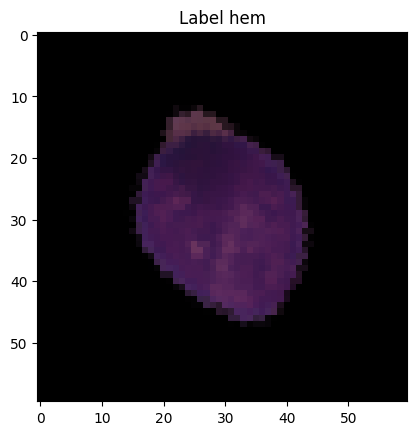

(60, 60, 3)


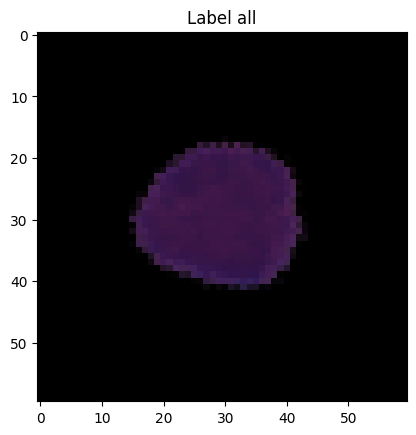

(60, 60, 3)


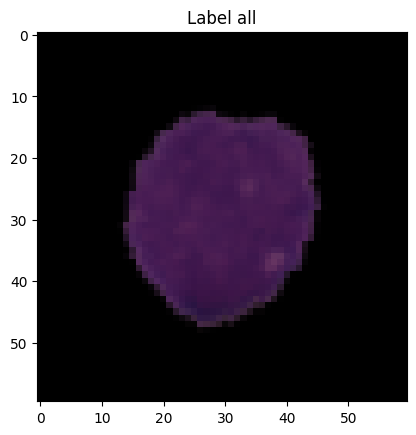

In [39]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset0.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

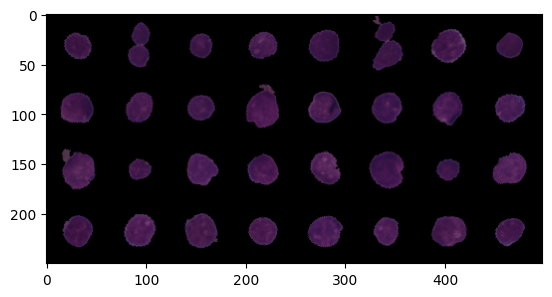

In [40]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

  
batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [41]:
3*60*60

10800

In [72]:
from torch import nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(10800, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 2)
)

device = "cuda"
model = model.to(device)

In [73]:
# функция ошибки для задачи многоклассовой классификации
loss_fn = nn.CrossEntropyLoss()

# оптимизатор Adam для обучения нейронной сети
optimizer = torch.optim.Adam(
    model.parameters(),   # параметры модели
    lr=0.2
)

# список для сохранения значений loss во время обучения
loss_list = []
loss_test_list = []

# цикл обучения по эпохам
for i in range(3):

    # перебор батчей из обучающего даталоадера
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        loss.backward()               # вычисление градиентов
        optimizer.step()              # обновление весов модели
        optimizer.zero_grad()         # очистка градиентов

        loss_list.append(loss.cpu().item())  # сохранение значения loss

    #test data
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        

        loss_test_list.append(loss.cpu().item())  # сохранение значения loss


loss: 0.7000043392181396
loss: 362.24432373046875
loss: 18.005558013916016
loss: 907.7620239257812
loss: 168.68301391601562
loss: 167.81027221679688
loss: 0.6586623787879944
loss: 0.6383218765258789
loss: 0.6217762231826782
loss: 0.6115574836730957
loss: 0.6518534421920776
loss: 0.6128215789794922
loss: 0.6869584918022156
loss: 0.673261284828186
loss: 0.619288444519043
loss: 0.7177205085754395
loss: 0.6208862066268921
loss: 0.6899495720863342
loss: 0.6958400011062622
loss: 0.654373288154602
loss: 0.7467545866966248
loss: 0.5793290138244629
loss: 0.6175165176391602
loss: 0.6760488748550415
loss: 0.6249294281005859
loss: 0.6151560544967651
loss: 0.596227765083313
loss: 0.644086480140686
loss: 0.6359040141105652
loss: 0.6462204456329346
loss: 0.6368690729141235
loss: 0.6238624453544617
loss: 0.6206855773925781
loss: 0.6542449593544006
loss: 0.6406179666519165
loss: 0.6246311664581299
loss: 0.6264075040817261
loss: 0.6281837224960327
loss: 0.6317363977432251
loss: 0.6441704630851746
loss: 

KeyboardInterrupt: 

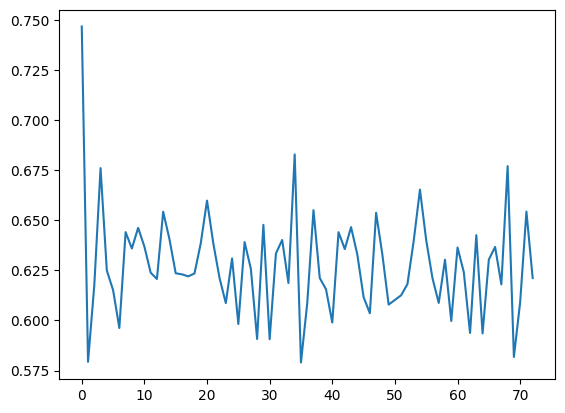

In [84]:
import matplotlib.pyplot as plt

new_list = loss_list[20 :]

plt.plot(new_list)



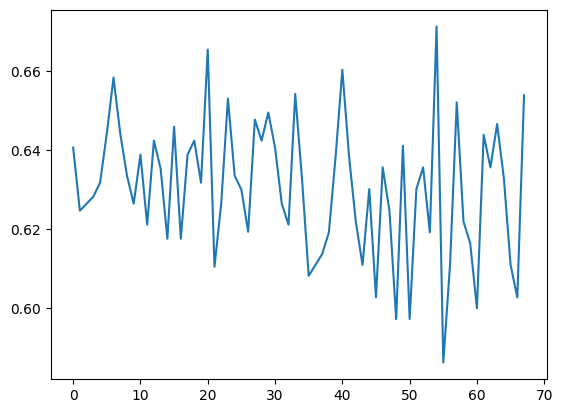

In [75]:
plt.plot(loss_test_list)

In [81]:
img, label = train_data[100]
img = img.unsqueeze(0)
img.shape

torch.Size([1, 3, 60, 60])

In [82]:
img = img.to(device)
prediction = model(img)
print(label)
print(nn.Softmax()(prediction))

1
tensor([[0.6806, 0.3194]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
